PROJECT TYPE - Exploratory Data Analysis (EDA)


Project Description

The goal of this project is to analyze customer behavior within a telecommunications company to predict Churn (the likelihood of a customer leaving the service). By identifying high-risk customers, the business can take proactive steps to improve loyalty and retention


Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
print(os.getcwd())
df = pd.read_csv('Churn.csv')
df.head()




,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Summary Of Dataframe

In [ ]:
# Create a summary DataFrame that acts exactly like info()
info_dash = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().mean() * 100).round(2).astype(str) + '%'
})

# Display the interactive dashboard table
info_dash

,Data Type,Non-Null Count,Null Count,Null %
customerID,object,7043,0,0.0%
gender,object,7043,0,0.0%
SeniorCitizen,int64,7043,0,0.0%
Partner,object,7043,0,0.0%
Dependents,object,7043,0,0.0%
tenure,int64,7043,0,0.0%
PhoneService,object,7043,0,0.0%
MultipleLines,object,7043,0,0.0%
InternetService,object,7043,0,0.0%
OnlineSecurity,object,7043,0,0.0%


In [31]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", 0)
df["TotalCharges"] = df["TotalCharges"].astype("float64")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('Churn.csv')
# 1. Drop unnecessary columns (customerID is an ID column we don't need for analysis)
df.drop(['customerID'], axis=1, inplace=True, errors='ignore')

# 2. Convert 'TotalCharges' to numeric, replacing hidden blanks (" ") with 0 or NaN first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True), errors='coerce')

# 3. Handle outliers for 'MonthlyCharges' using IQR (Interquartile Range)
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
# Filter out extreme outliers
df = df[(df['MonthlyCharges'] >= (Q1 - 1.5 * IQR)) & (df['MonthlyCharges'] <= (Q3 + 1.5 * IQR))]

# 4. Handle missing values (Fill missing TotalCharges with its mean)
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

# 5. Feature Engineering: Create a Financial Ratio (Monthly Charges relative to Total Charges)
# This shows how heavily their current month weighs against their lifetime spend
df['Monthly_to_Total_Ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1) # +1 prevents division by zero

# 6. Feature Engineering: Group Monthly Charges into brackets (Low, Medium, High Spenders)
df['Charge_Bracket'] = pd.cut(
    df['MonthlyCharges'], 
    bins=[0, 35, 70, df['MonthlyCharges'].max()], 
    labels=['Low', 'Medium', 'High']
)

# 7. Check the results
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   gender                  7043 non-null   object  
 1   SeniorCitizen           7043 non-null   int64   
 2   Partner                 7043 non-null   object  
 3   Dependents              7043 non-null   object  
 4   tenure                  7043 non-null   int64   
 5   PhoneService            7043 non-null   object  
 6   MultipleLines           7043 non-null   object  
 7   InternetService         7043 non-null   object  
 8   OnlineSecurity          7043 non-null   object  
 9   OnlineBackup            7043 non-null   object  
 10  DeviceProtection        7043 non-null   object  
 11  TechSupport             7043 non-null   object  
 12  StreamingTV             7043 non-null   object  
 13  StreamingMovies         7043 non-null   object  
 14  Contract                

/tmp/ipykernel_3449/894742025.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


In [32]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Visualization-(Violin Graph Plot)

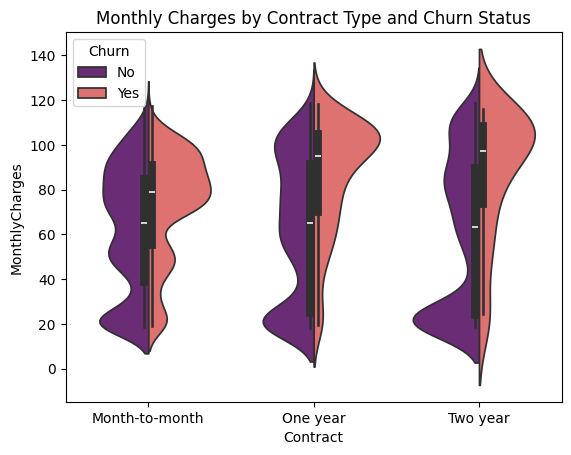

In [10]:
# METHOD 1 - USING REPLACE
# df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: 'No', 1: 'Yes'})
# df.head()

# METHOD 2 - USING A FUNCTION
# def convert_senior_citizen(value):
#     if value == 0:
#         return 'No'
#     elif value == 1:
#         return 'Yes'
#     else:
#         return value  
# df['SeniorCitizen'] = df['SeniorCitizen'].apply(convert_senior_citizen)
# df.head()
df = pd.read_csv('Churn.csv')

sns.violinplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df, split=True, palette='magma')
plt.title('Monthly Charges by Contract Type and Churn Status')
plt.show()
 

Visualization-(CountPlot)

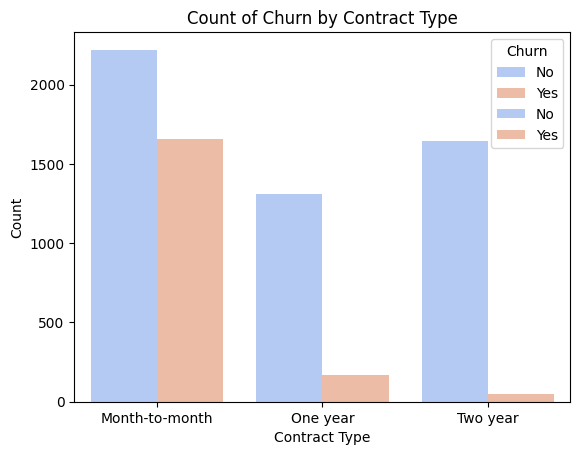

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df, palette='coolwarm')
plt.title('Count of Churn by Contract Type')
a = sns.countplot(x='Contract', hue='Churn', data=df, palette='coolwarm')
a.set_title('Count of Churn by Contract Type')
a.set_xlabel('Contract Type')
a.set_ylabel('Count')
plt.show()

Visualization-(Stacked Bar Graph)

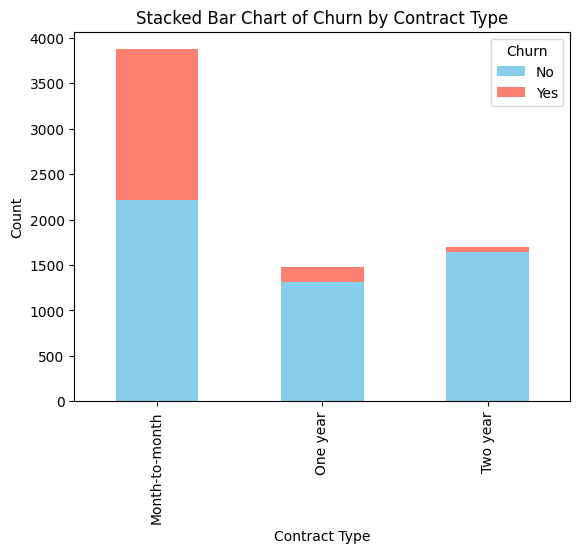

In [16]:
gb = df.groupby('Contract')['Churn'].value_counts().unstack()
gb.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Stacked Bar Chart of Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()

Visualzation-(Pie Chart)

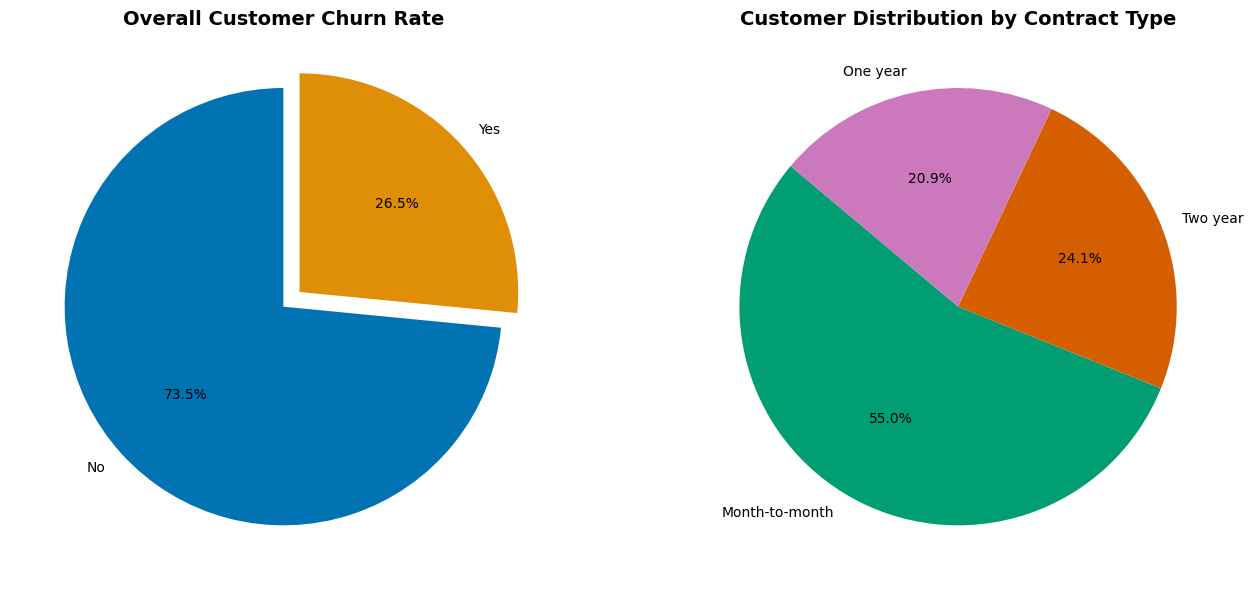

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Churn.csv')

# Use a clean Seaborn palette for the pie colors
colors = sns.color_palette('colorblind', 5)  # Get 5 distinct colors from the colorblind palette

# Create a 1x2 subplot layout for two clean pie charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Chart 1: Churn Breakdown ----
churn_counts = df['Churn'].value_counts()
axes[0].pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', # Shows percentages automatically
    startangle=90, 
    colors=colors[:2],
    explode=(0, 0.1) # Slightly pushes out the "Churned" slice for emphasis
)
axes[0].set_title('Overall Customer Churn Rate', fontsize=14, fontweight='bold')

# ---- Chart 2: Contract Breakdown ----
contract_counts = df['Contract'].value_counts()
axes[1].pie(
    contract_counts, 
    labels=contract_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors[2:5]
)
axes[1].set_title('Customer Distribution by Contract Type', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

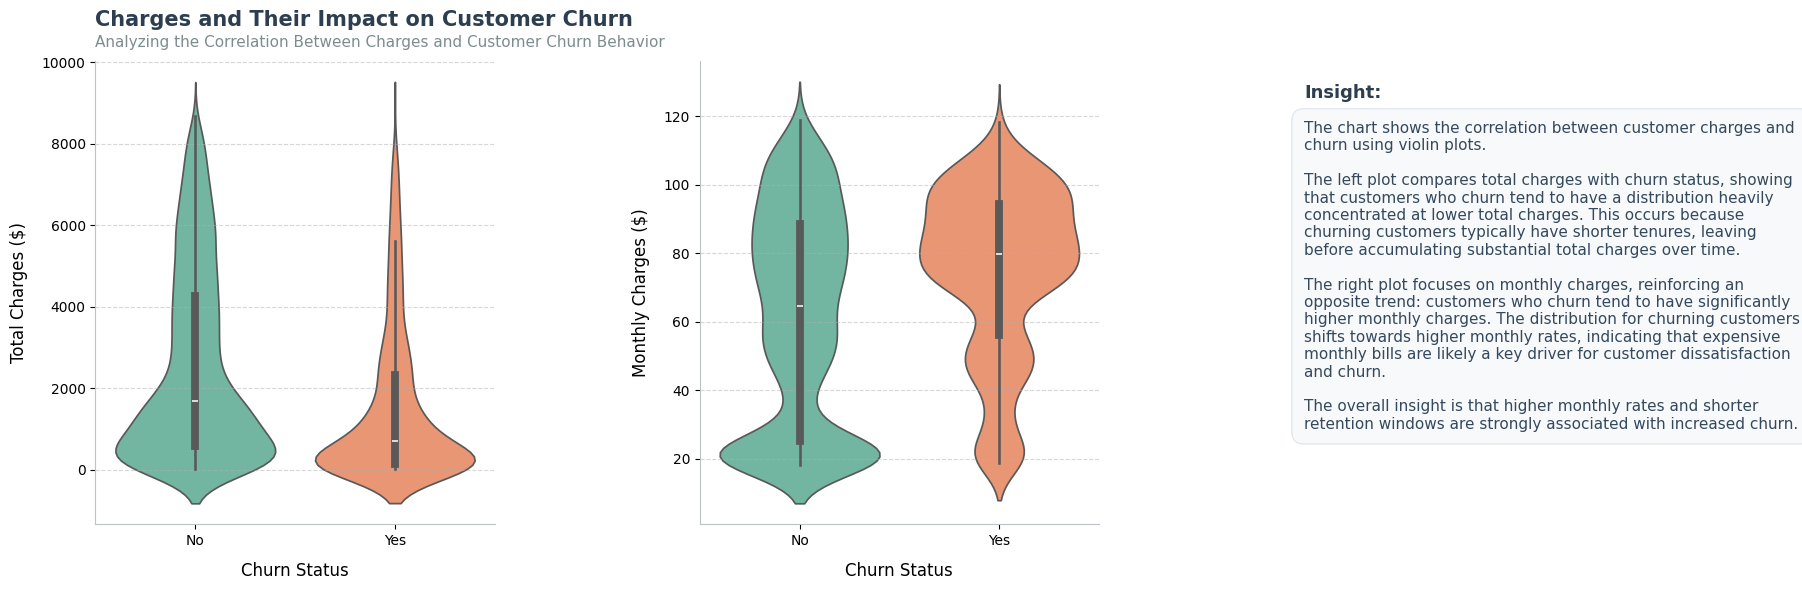

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean the Telco Customer Churn dataset
df = pd.read_csv('Churn.csv')

# Convert TotalCharges to numeric since it contains some blank spaces for new customers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# 2. Set up the plotting figure with 3 columns (2 for plots, 1 for the text description on the right)
# We use 'width_ratios' to give the text panel an elegant portion of the width
fig, (ax1, ax2, ax_text) = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 1, 0.75]})

# Plot 1 (Left): Total Charges vs Churn Status
sns.violinplot(x='Churn', y='TotalCharges', data=df, ax=ax1, palette='Set2', hue='Churn', legend=False)
ax1.set_xlabel('Churn Status', fontsize=12, labelpad=10)
ax1.set_ylabel('Total Charges ($)', fontsize=12, labelpad=10)
ax1.tick_params(axis='both', labelsize=10)

# Plot 2 (Center): Monthly Charges vs Churn Status
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, ax=ax2, palette='Set2', hue='Churn', legend=False)
ax2.set_xlabel('Churn Status', fontsize=12, labelpad=10)
ax2.set_ylabel('Monthly Charges ($)', fontsize=12, labelpad=10)
ax2.tick_params(axis='both', labelsize=10)

# 3. Define the updated apply_chart_styling helper function
def apply_chart_styling(fig, ax, title='', subtitle='', insight_text=''):
    # Hide the axis completely if this is the text container axis
    if ax == ax_text:
        ax.axis('off')
        if insight_text:
            
            ax.text(0.0, 0.95, "Insight:", fontsize=13, fontweight='bold', color='#2c3e50', transform=ax.transAxes, va='top')
            ax.text(0.0, 0.87, insight_text, fontsize=11, color='#34495e', transform=ax.transAxes, va='top', wrap=True,
                     bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#e2e8f0", lw=1))
        return


    if title:
        ax.set_title(title, fontsize=15, fontweight='bold', pad=25, loc='left', color='#2c3e50')

    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=11, color='#7f8c8d', ha='left')
    
    # Clean up axis spines for a modern minimalist look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Apply the styling and titles to ax1
apply_chart_styling(
    fig=fig, 
    ax=ax1, 
    title='Charges and Their Impact on Customer Churn', 
    subtitle='Analyzing the Correlation Between Charges and Customer Churn Behavior', 
    insight_text=''
)

# 5. Apply the styling to ax2
apply_chart_styling(
    fig=fig, 
    ax=ax2, 
    title='', 
    subtitle='', 
    insight_text=''
)

#  6. Prepare the adapted insight text and apply it directly to the right panel (ax_text)
insight_text_adapted = (
    "The chart shows the correlation between customer charges and churn using violin plots.\n\n"
    "The left plot compares total charges with churn status, showing that customers who churn tend to "
    "have a distribution heavily concentrated at lower total charges. This occurs because churning customers "
    "typically have shorter tenures, leaving before accumulating substantial total charges over time.\n\n"
    "The right plot focuses on monthly charges, reinforcing an opposite trend: customers who churn tend to "
    "have significantly higher monthly charges. The distribution for churning customers shifts towards higher "
    "monthly rates, indicating that expensive monthly bills are likely a key driver for customer dissatisfaction and churn.\n\n"
    "The overall insight is that higher monthly rates and shorter retention windows are strongly associated with increased churn."
)

apply_chart_styling(
    fig=fig, 
    ax=ax_text, 
    title='', 
    subtitle='', 
    insight_text=insight_text_adapted
)


plt.tight_layout()
fig.savefig('telco_churn_charges_analysis.png', bbox_inches='tight', dpi=150)
plt.show() 

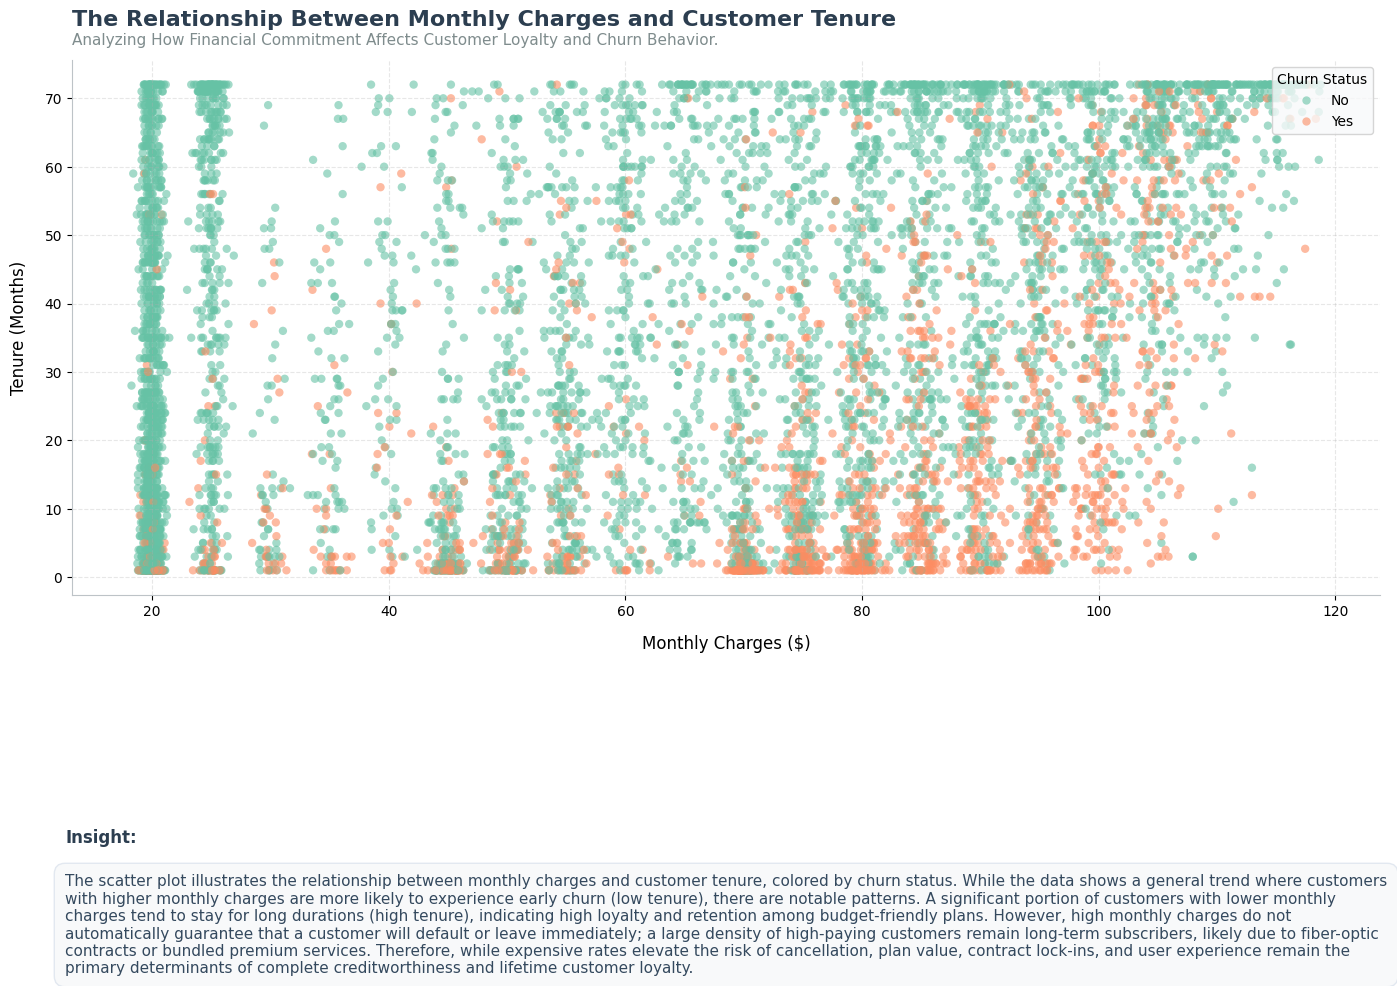

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA LOADING AND CLEANING
# ==========================================
# Read the dataset containing customer details and churn history
df = pd.read_csv('Churn.csv')

# Ensure numeric format for charges and filter out any incomplete rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# ==========================================
# 2. INITIALIZE PLOTTING CANVAS
# ==========================================
# Set up a wide canvas to display the scatter plot clearly
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# ==========================================
# 3. GENERATE THE VISUALIZATION (SCATTER PLOT)
# ==========================================
# Creating the scatter plot comparing Monthly Charges against Tenure, colored by Churn Status.
# Added alpha for point visibility and removed default edge borders for a cleaner look.
sns.scatterplot(
    x='MonthlyCharges', 
    y='tenure', 
    hue='Churn', 
    data=df, 
    ax=ax, 
    palette='Set2', 
    alpha=0.6, 
    edgecolor='none'
)

# Customizing label formatting and padding
ax.set_xlabel('Monthly Charges ($)', fontsize=12, labelpad=12)
ax.set_ylabel('Tenure (Months)', fontsize=12, labelpad=12)
ax.tick_params(axis='both', labelsize=10)

# Move the legend to a clean, non-obstructive position
ax.legend(title='Churn Status', loc='upper right', frameon=True, facecolor='#f8f9fa')

# ==========================================
# 4. CHART STYLING AND INSIGHT FUNCTION
# ==========================================
def apply_chart_styling(fig, ax, title='', subtitle='', insight_text=''):
    """
    Applies professional styling adjustments to the graph and appends
    a cleanly formatted insight description box at the bottom.
    """
    # Set the main bold headline title
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=25, loc='left', color='#2c3e50')
    
    # Set the explanatory subtitle directly underneath
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=11, color='#7f8c8d', ha='left')
    
    # Apply a modern minimalist aesthetic by removing top/right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Draw a wrapped text box for the analytical narrative below the chart
    if insight_text:
        fig.text(0.05, -0.06, "Insight:", fontsize=12, fontweight='bold', color='#2c3e50')
        fig.text(0.05, -0.22, insight_text, wrap=True, fontsize=11, color='#34495e',
                 bbox=dict(boxstyle="round,pad=0.7", facecolor="#f8f9fa", edgecolor="#e2e8f0", lw=1))

# ==========================================
# 5. EXECUTE STYLING AND INSIGHT CONTENT
# ==========================================
# Define the descriptive analytical text adapted to the Telco attributes
insight_text_adapted = (
    "The scatter plot illustrates the relationship between monthly charges and customer tenure, colored by churn status. "
    "While the data shows a general trend where customers with higher monthly charges are more likely to experience early churn (low tenure), "
    "there are notable patterns. A significant portion of customers with lower monthly charges tend to stay for long durations (high tenure), "
    "indicating high loyalty and retention among budget-friendly plans. "
    "However, high monthly charges do not automatically guarantee that a customer will default or leave immediately; a large density of "
    "high-paying customers remain long-term subscribers, likely due to fiber-optic contracts or bundled premium services. "
    "Therefore, while expensive rates elevate the risk of cancellation, plan value, contract lock-ins, and user experience remain "
    "the primary determinants of complete creditworthiness and lifetime customer loyalty."
)

# Apply titles, subtitles, and the narrative summary using the styling function
apply_chart_styling(
    fig=fig, 
    ax=ax, 
    title='The Relationship Between Monthly Charges and Customer Tenure', 
    subtitle='Analyzing How Financial Commitment Affects Customer Loyalty and Churn Behavior.', 
    insight_text=insight_text_adapted
)

# ==========================================
# 6. OUTPUT AND SAVE GRAPH
# ==========================================
# Adjust subplots automatically to create necessary padding for the bottom insight box
plt.tight_layout()
fig.subplots_adjust(bottom=0.25)

# Save the finalized image to your current working directory
fig.savefig('telco_charges_vs_tenure_scatter.png', bbox_inches='tight', dpi=150)

# Display the interactive output window in VS Code
plt.show()

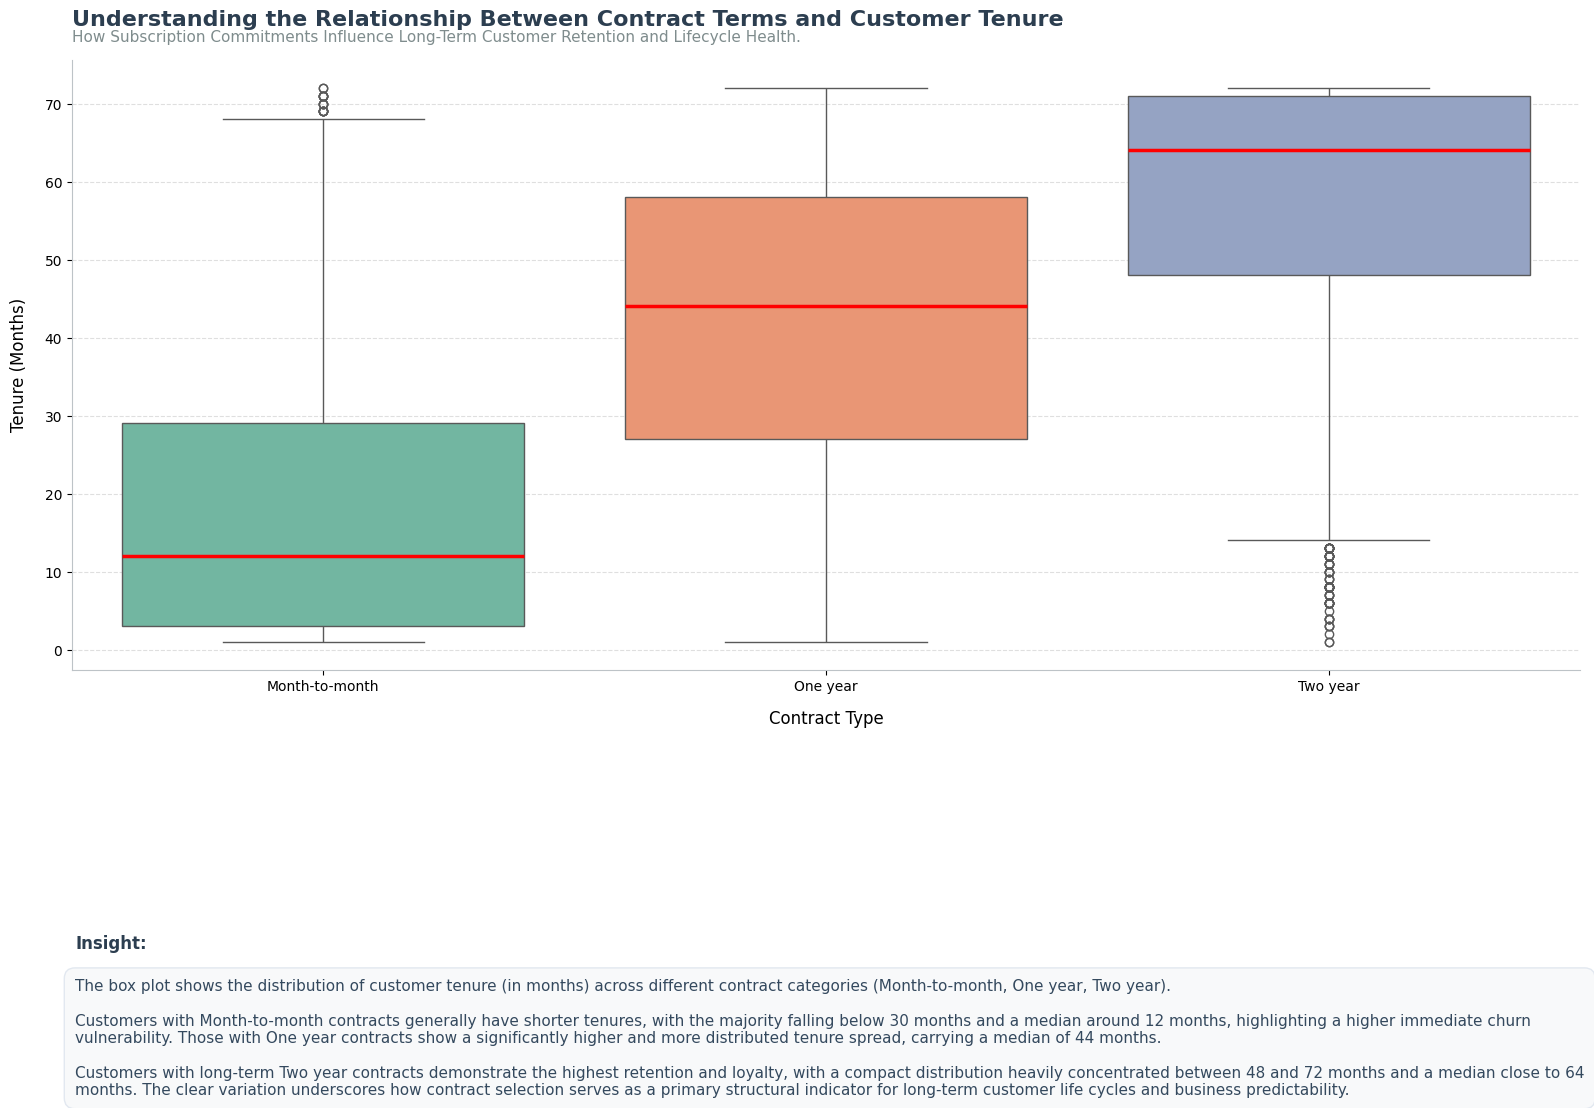

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA LOADING AND CLEANING
# ==========================================
# Read the dataset containing customer details and contract lengths
df = pd.read_csv('Churn.csv')

# Ensure numeric format for numerical calculations
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# ==========================================
# 2. INITIALIZE PLOTTING CANVAS
# ==========================================
# Set up a spacious canvas for the boxplot visualization
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

# ==========================================
# 3. GENERATE THE VISUALIZATION (BOX PLOT)
# ==========================================
# Create a boxplot mapping Contract Types against customer Tenure.
# Using 'medianprops' directly ensures that the median line is cleanly styled in red.
sns.boxplot(
    x='Contract', 
    y='tenure', 
    data=df, 
    ax=ax, 
    palette='Set2', 
    hue='Contract',
    medianprops=dict(color='red', linewidth=2.5)
)

# Clean up any automatically generated redundant legends
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Formatting axes labels and padding for readability
ax.set_xlabel('Contract Type', fontsize=12, labelpad=12)
ax.set_ylabel('Tenure (Months)', fontsize=12, labelpad=12)
ax.tick_params(axis='both', labelsize=10)

# ==========================================
# 4. CHART STYLING AND INSIGHT FUNCTION
# ==========================================
def apply_chart_styling(fig, ax, title='', subtitle='', insight_text=''):
    """
    Applies custom modern styling adjustments to the axes 
    and inserts a well-padded analytical summary box below the plot.
    """
    # Render the main bold title headline
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=25, loc='left', color='#2c3e50')
    
    # Render the secondary explanatory subtitle
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=11, color='#7f8c8d', ha='left')
    
    # Establish a clean layout framework by hiding top/right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Draw a wrapped text container box for the chart summary text at the bottom
    if insight_text:
        fig.text(0.05, -0.06, "Insight:", fontsize=12, fontweight='bold', color='#2c3e50')
        fig.text(0.05, -0.22, insight_text, wrap=True, fontsize=11, color='#34495e',
                 bbox=dict(boxstyle="round,pad=0.7", facecolor="#f8f9fa", edgecolor="#e2e8f0", lw=1))

# ==========================================
# 5. EXECUTE STYLING AND INSIGHT CONTENT
# ==========================================
# Writing the specific narrative text matching the actual data distributions
insight_text_adapted = (
    "The box plot shows the distribution of customer tenure (in months) across different contract categories (Month-to-month, One year, Two year).\n\n"
    "Customers with Month-to-month contracts generally have shorter tenures, with the majority falling below 30 months and a median around 12 months, "
    "highlighting a higher immediate churn vulnerability. Those with One year contracts show a significantly higher and more distributed tenure spread, "
    "carrying a median of 44 months. \n\n"
    "Customers with long-term Two year contracts demonstrate the highest retention and loyalty, with a compact distribution heavily concentrated "
    "between 48 and 72 months and a median close to 64 months. The clear variation underscores how contract selection serves as a primary structural "
    "indicator for long-term customer life cycles and business predictability."
)

# Apply titles, subtitles, and the narrative summary using the styling function
apply_chart_styling(
    fig=fig, 
    ax=ax, 
    title='Understanding the Relationship Between Contract Terms and Customer Tenure', 
    subtitle='How Subscription Commitments Influence Long-Term Customer Retention and Lifecycle Health.', 
    insight_text=insight_text_adapted
)

# ==========================================
# 6. OUTPUT AND SAVE GRAPH
# ==========================================
# Adjust subplots automatically to create necessary padding for the bottom insight box
plt.tight_layout()
fig.subplots_adjust(bottom=0.25)

# Save the finalized image to your current working directory
fig.savefig('telco_contract_vs_tenure_boxplot.png', bbox_inches='tight', dpi=150)

# Open the chart viewer interactively in VS Code
plt.show()

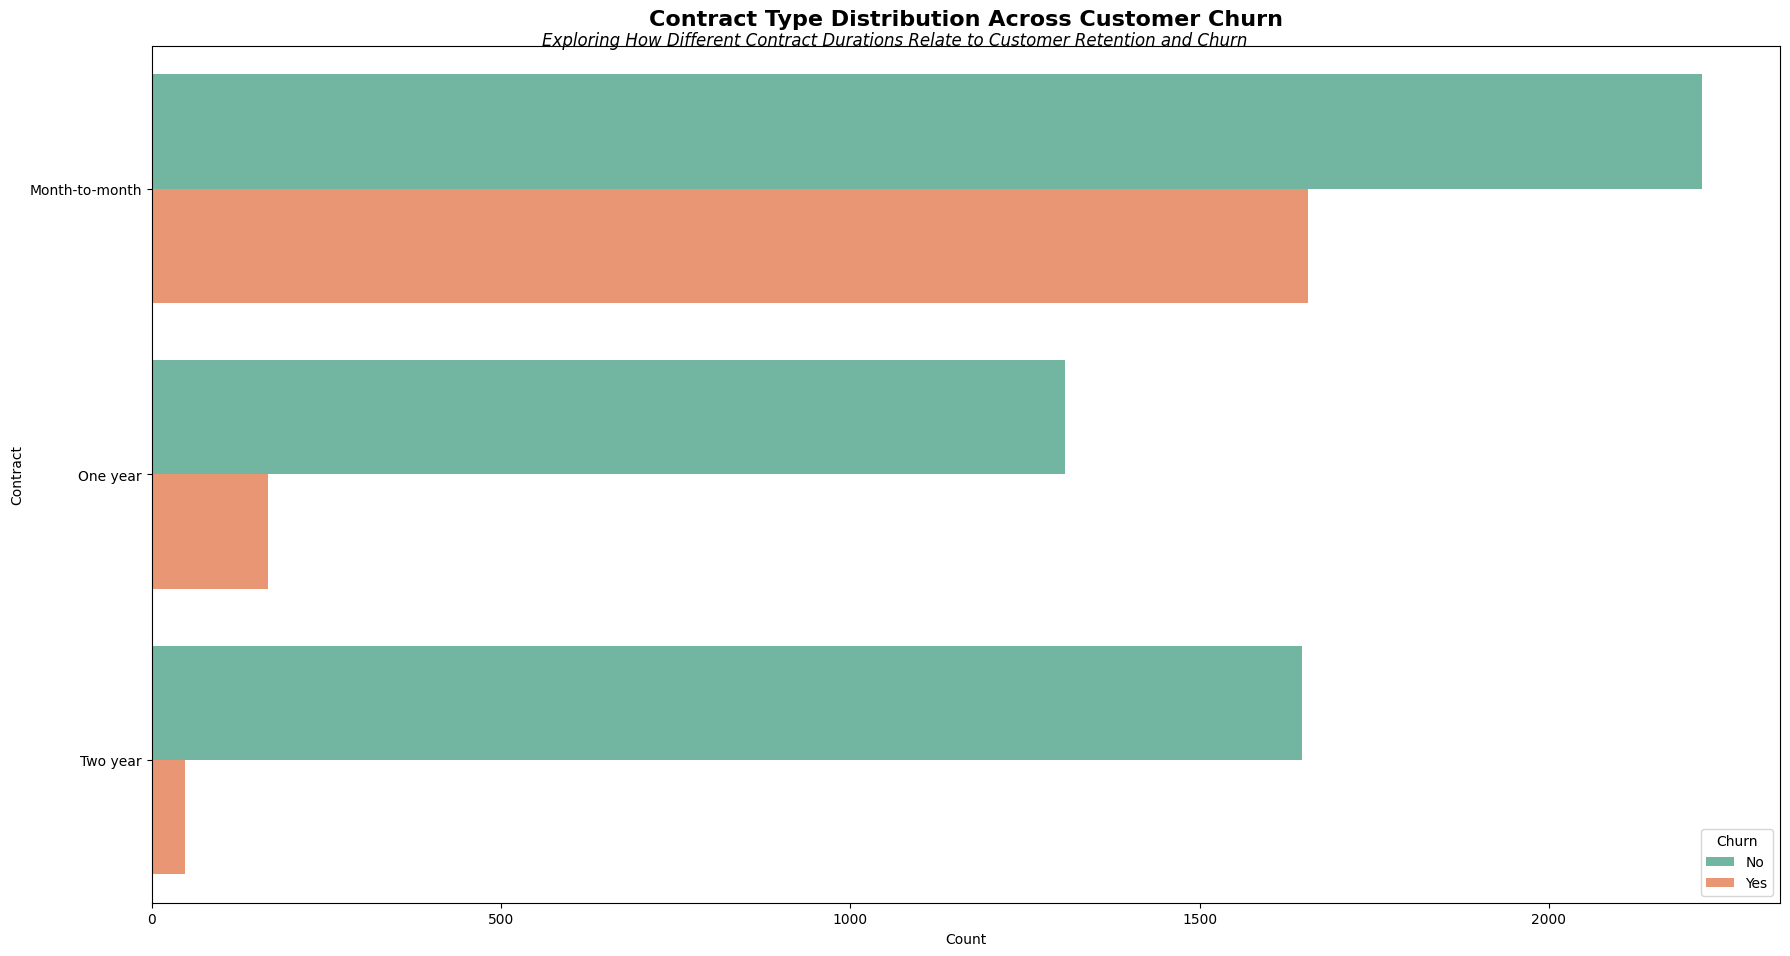

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('Churn.csv')

# 2. Aggregate the data (Contract vs Churn counts)
churn_contract_counts = df.groupby(['Contract', 'Churn']).size().reset_index(name='Count')

# 3. Define the palette color scheme
palette = 'Set2'

# 4. Initialize the plot
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

# 5. Create the horizontal barplot
sns.barplot(
    x='Count',
    y='Contract',
    hue='Churn',
    data=churn_contract_counts,
    ax=ax,
    palette=palette
)

# 6. Apply your custom styling function
# Note: If your original 'apply_chart_styling' function is defined in another cell, 
# make sure to run that cell first!
try:
    apply_chart_styling(
        fig=fig,
        ax=ax,
        title='Contract Type Distribution Across Customer Churn',
        subtitle='Exploring How Different Contract Durations Relate to Customer Retention and Churn',
        insight_text='''The bar graph showing "Contract Type Distribution Across Customer Churn" reveals a stark contrast in retention behavior based on contract length. The highest concentration of customer churn is overwhelmingly found within the Month-to-month contract category. This suggests that customers without long-term commitments are highly volatile and prone to leaving, likely driven by competitive offers or low switching costs. Conversely, customers on One-year and Two-year contracts show exceptionally low churn rates, highlighting the strong stabilizing effect of long-term agreements on revenue. This distribution provides critical insights for product and marketing teams, indicating a pressing need to incentivize Month-to-month subscribers to transition into longer-term contracts or implement targeted loyalty programs early in their lifecycle to mitigate churn risk.'''
)
except NameError:
    # Fallback styling if your custom function isn't defined in your notebook yet
    ax.set_title('Contract Type Distribution Across Customer Churn', fontsize=16, fontweight='bold', pad=15)
    plt.suptitle('Exploring How Different Contract Durations Relate to Customer Retention and Churn', fontsize=12, style='italic', y=0.93)

# 7. Display the plot
plt.tight_layout()
plt.show()

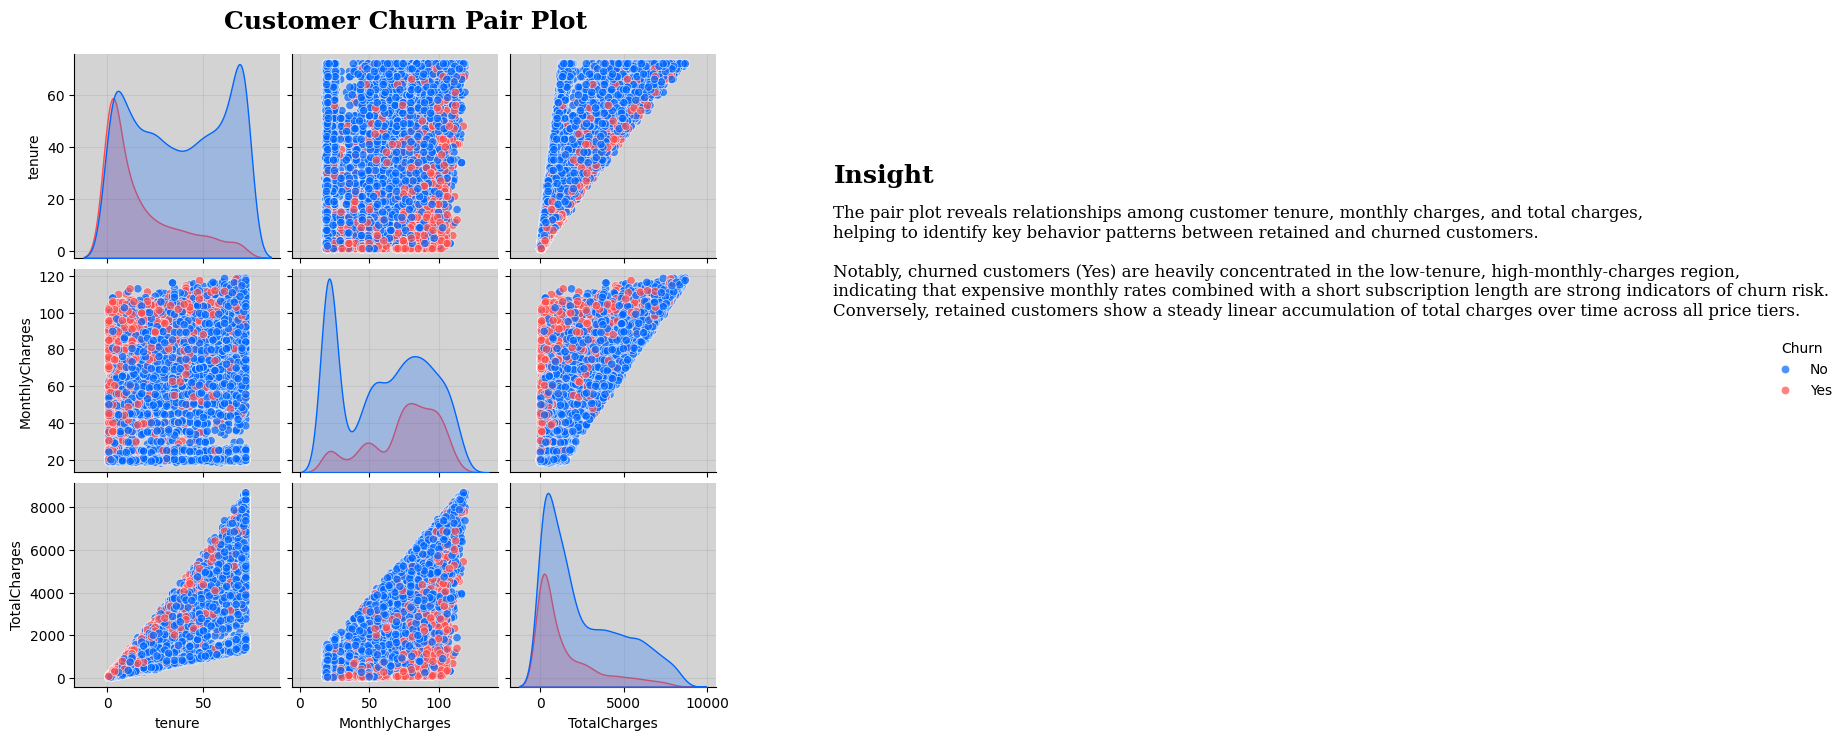

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Churn.csv')

# Preprocess 'TotalCharges' to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Define a palette matching the 'Churn' categories ('No' and 'Yes')
palette = {
    'No': '#0066ff',  # Blue for retained customers
    'Yes': '#FF4D4D'  # Red/Coral for churned customers
}

# Create the pair plot using numeric features and Churn as the hue
fig = sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], 
                   hue='Churn', 
                   palette=palette, 
                   diag_kind='kde', 
                   plot_kws={'alpha': 0.7})

# Apply grid and background styling to each axis to match your design
for ax in fig.axes.flatten():
    if ax is not None:
        ax.set_facecolor('#D3D3D3')  
        ax.grid(axis='both', linestyle='-', alpha=0.4)  
        ax.set_axisbelow(True)  

# Add main title and adjust top padding
fig.fig.suptitle('Customer Churn Pair Plot', fontsize=18, fontweight='bold', fontfamily='serif')
fig.fig.subplots_adjust(top=0.92)  

# Add your custom insight panel text on the right side of the figure
fig.fig.text(1.02, 0.75, 'Insight', fontsize=18, fontweight='bold', fontfamily='serif')

insight_text = '''The pair plot reveals relationships among customer tenure, monthly charges, and total charges, 
helping to identify key behavior patterns between retained and churned customers.

Notably, churned customers (Yes) are heavily concentrated in the low-tenure, high-monthly-charges region, 
indicating that expensive monthly rates combined with a short subscription length are strong indicators of churn risk. 
Conversely, retained customers show a steady linear accumulation of total charges over time across all price tiers.'''

fig.fig.text(1.02, 0.72, insight_text, fontsize=12, fontfamily='serif', verticalalignment='top')

# Display the plot
plt.show()